In [1]:
# Polynomial fit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Advertising.csv").iloc[:,1:]
df.head()
df_small = df.iloc[0:100,[0,-1]]
df_small

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9
...,...,...
95,163.3,16.9
96,197.6,11.7
97,184.9,15.5
98,289.7,25.4


In [3]:
xInput = df_small.iloc[np.r_[11:51],0].values
yInput = df_small.iloc[np.r_[11:51],-1].values
xTest = df_small.iloc[0:11,0].values
yTest = df_small.iloc[0:11,1].values

In [4]:
# Polynomial fit
class polyFit:
    def __init__(self):
        self.n = 0
        self.x = 0
        self.y = 0

    def modelFit(self, xInput, n):
        for i in range(1, n+1):
            xSub = xInput.reshape(-1,1) ** i
            if (i == 1):
                x = np.hstack( [ xSub, np.ones((len(xInput),1)) ]) # x matrix for training data
            else:
                x = np.hstack([xSub, x]) # x matrix for training data
        return x

    def minFind(self, x, y):
        # Apply normal equation to find minimum for slopes and y-intercept parameters
        xtx = x.T @ x
        w = np.linalg.inv(xtx) @ x.T @ y
        return w

    def polyPlot(self, w, xInput, yInput, xTest, yTest):
        wReversed = w[::-1]
        xPlot = np.arange(0, max(xInput)+100, 0.1)
        for i in range(0, len(wReversed)):
            if (i == 0):
                yPlot = wReversed[i]
            if (i > 0):
                yPlot = wReversed[i] * xPlot ** i + yPlot

        dist = 0
        for j in range(0, xTest.size):
            idx = (np.abs(xPlot - xTest[j])).argmin()
            dist = (yTest[j] - yPlot[idx]) + dist
        avg = dist / xTest.size
        print("Average residual distance for test data: ", avg)
        
        # plot
        plt.scatter(xInput, yInput, marker = "*", color = 'r') # training data
        plt.scatter(xTest, yTest, marker = 's', color = 'g') # test data
        plt.title(print("Polynomial fit: degree = ", len(w)-1))
        plt.plot(xPlot, yPlot, color = 'b', linestyle = '--')
        plt.show()

Average residual distance for test data:  -0.015627333618220038
Polynomial fit: degree =  1


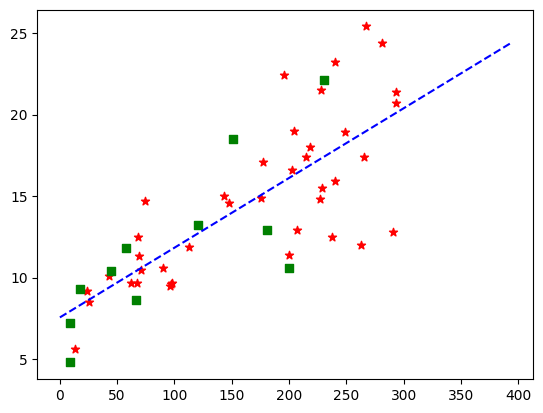

Average residual distance for test data:  0.06448176548841224
Polynomial fit: degree =  2


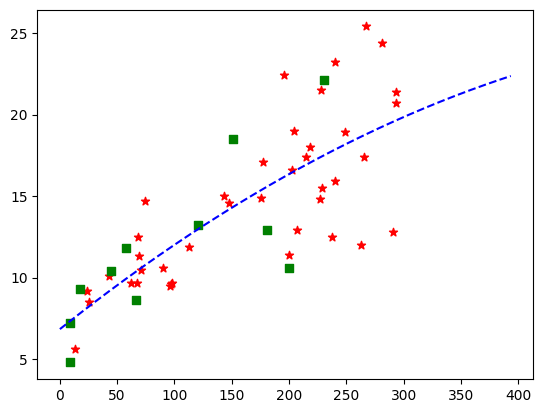

Average residual distance for test data:  0.056904433058520484
Polynomial fit: degree =  3


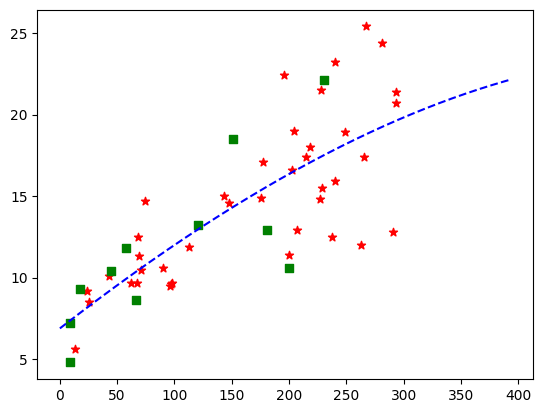

Average residual distance for test data:  0.14132400763693473
Polynomial fit: degree =  4


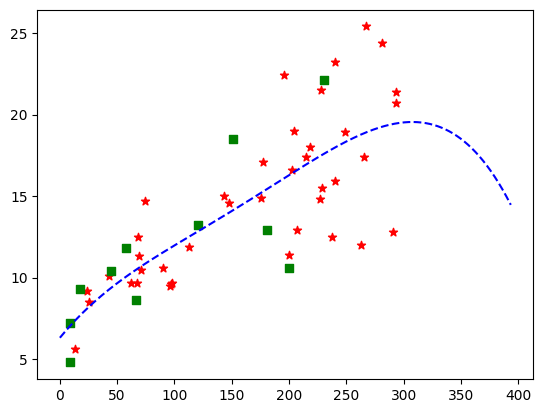

Average residual distance for test data:  0.32665668039381707
Polynomial fit: degree =  5


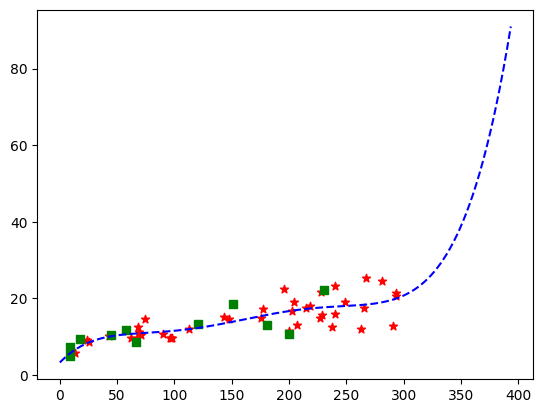

Average residual distance for test data:  0.6742620366648453
Polynomial fit: degree =  6


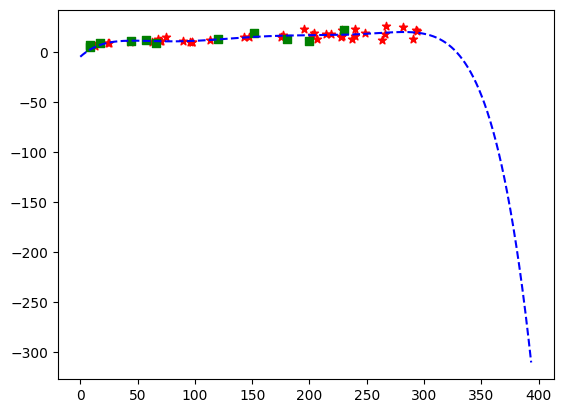

Average residual distance for test data:  0.31688424659220277
Polynomial fit: degree =  7


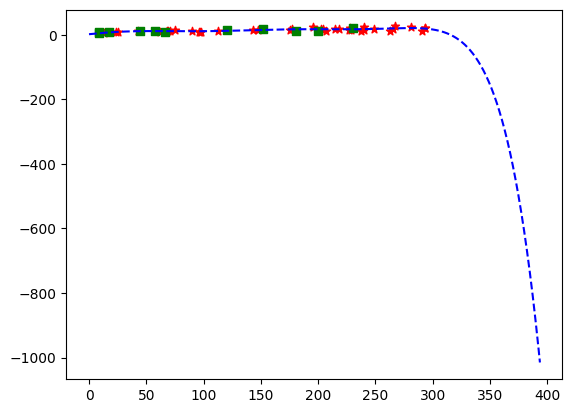

Average residual distance for test data:  0.26640456662783163
Polynomial fit: degree =  8


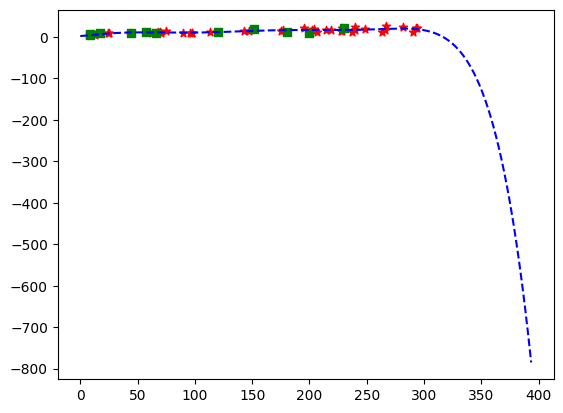

Average residual distance for test data:  0.23062757791256724
Polynomial fit: degree =  9


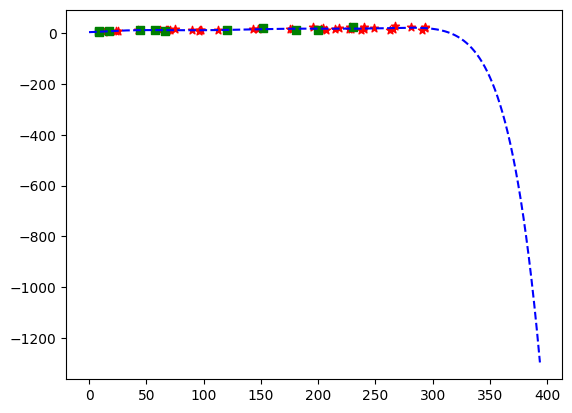

In [5]:
for i in range(1, 10):
    p = polyFit()
    x = p.modelFit(xInput, i) # returns x matrix fit to polynomial
    w = p.minFind(x, yInput) # returns minimum values for features in polynomial
    p.polyPlot(w, xInput, yInput, xTest, yTest)